# Attendance

[The link to SEAts](https://gold.seats.cloud/angular/#/lectures)

[Evaluations!](http://www.doc.gold.ac.uk/evaluation) 🙏

# 16 Text generation

In [1]:
import os
import sys
import json
import pathlib
from functools import partial

import numpy as np

import tensorflow as tf

import matplotlib.pyplot as plt

os.environ["KERAS_BACKEND"] = "jax"
# Free up more GPU memory on the Jax and TensorFlow backends.
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "1.00"

import keras
import keras_hub
import kagglehub

keras.config.set_dtype_policy("mixed_float16")

from IPython.display import clear_output
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

In [2]:
# a custom callback that prints training stats without cluttering the notebook
# ported and expanded from lectures/04/chapter05_fundamentals-of-ml
# and see: https://chatgpt.com/share/69aeecc7-bb80-8005-a441-80e4cc062606
class PrintStatsCallback(keras.callbacks.Callback):
    def __init__(self, epochs):
        super(keras.callbacks.Callback, self).__init__()
        self.epochs = epochs
        self.current_epoch = 0
        self.total_train_batches = None
        self.total_test_batches = None
    def print_stats(self, batch=None, val_batch=None):
        # print train stats
        tot = self.total_train_batches if self.total_train_batches is not None else "unknown"
        current_batch = batch + 1 if batch is not None else tot
        msg = f"epoch: {self.current_epoch+1}/{self.epochs}"
        fmt = len(str(tot))
        print(f"{msg} |     batch: {current_batch:>{fmt}}/{tot:>{fmt}} | {self._metrics}")
        # print val stats (including past ones for readability)
        if hasattr(self, "_val_metrics"):
            val_tot = self.total_test_batches if self.total_test_batches is not None else "unknown"
            current_val_batch = val_batch + 1 if val_batch is not None else val_tot
            print(f"{' ' * len(msg)} | val batch: {current_val_batch:>{fmt}}/{val_tot:>{fmt}} | {self._val_metrics}")
    def on_train_batch_end(self, batch, logs=None):
        self._max_batch_seen = batch
        clear_output(wait=True)
        self._metrics = " – ".join(f"{k:>{len(k) + 4}}: {v:.4f}" for k, v in logs.items())
        self.print_stats(batch=batch)
    def on_test_batch_end(self, batch, logs=None):
        self._max_test_batch_seen = batch
        clear_output(wait=True)
        self._val_metrics = " – ".join(f"{f'val_{k}':>{len(k) + 4}}: {v:.4f}" for k, v in logs.items())
        self.print_stats(val_batch=batch)
    def on_epoch_begin(self, epoch, logs=None):
        self.current_epoch = epoch
        self._max_batch_seen = 0
    def on_epoch_end(self, epoch, logs=None):
        if self.total_train_batches is None:
            self.total_train_batches = self._max_batch_seen + 1
    def on_test_end(self, logs=None):
        if self.total_test_batches is None:
            self.total_test_batches = self._max_test_batch_seen + 1
    def on_train_end(self, logs=None):
        print()

In [3]:
def plot_history(history, metric):
    accuracy = history.history[metric]
    val_accuracy = history.history[f"val_{metric}"]
    epochs = range(1, len(accuracy) + 1)

    plt.plot(epochs, accuracy, "r--", label=f"Training {metric}")
    plt.plot(epochs, val_accuracy, "b", label=f"Validation {metric}")
    plt.title(f"Training and validation {metric}")
    plt.legend()
    plt.show()

---

## Text generation

Neural networks can generate new sequence data:

- text (all kinds, including summaries, dialogue);
- music (samples, notes);
- speech synthesis;
- handwriting or brushstrokes recorded on an iPad;
- even images, if considered like a sequence of pixels!

Deep learning algorithms can learn a statistical **latent space**: a structured compression or *distillation* of the data.

That space, like word embeddings, displays remarkable properties, and *can be explored*!

**Sampling from the latent space** 'creates' new artworks similar to the training data.

Chollet claims that this removes the barriers of craft and skills, to allow for more straightforward expression.

In my own experience, I find that it **shifts** the craft and skills needed elsewhere, rather than removing those.

*"What I cannot create, I don't understand."* – Richard P. Feynman

Perhaps another key motivation for Deep Learning researchers and engineers to pursue the generative route.

More history in the references notebook and [in the book](https://deeplearningwithpython.io/chapters/chapter16_text-generation/#a-brief-history-of-sequence-generation).

#### How do you generate sequence data?

Train a network to predict the next token(s) in a sequence using the previous tokens as input.

Source for tokens:  words, characters, samples, pixels, byte.

Any *text-based* model is known as a **language model**.

A language model captures the *latent space* of language i.e. its **statistical structure**.

The model will output a **probability distribution** over the next tokens: this is actually the same set-up as **single-label multi-class classification task** (input is the sequence so far, the label is the next token)!!

Given that we only have a target sequence, we will only need to use the **Transformer Decoder** (so only self-attention on the sequence we are currently generating).

#### Reminder: Auto-regressive generation

<!-- ![Chollet, text generation](images/chollet/auto-regressive.p.367.png) -->
<img src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/09/images/chollet/auto-regressive.p.367.png">

DLWP, 2<sup>nd</sup> edition, p.368

---

## Training a mini-GPT

### Dataset loading & processing

In [4]:
TEXTGEN_DIR = pathlib.Path("text-generation")
TEXTGEN_DIR.mkdir(exist_ok=True)

DATASET_DIR = pathlib.Path(TEXTGEN_DIR / "datasets")
DATASET_DIR.mkdir(exist_ok=True)

MODELS_DIR = pathlib.Path("models")
MODELS_DIR.mkdir(exist_ok=True)

# training on our own files (false: train on Mini-C4)
USE_CUSTOM_DATASET = True

# to train a sentencepiece tokenizer from scracth, you must have the
# sentencepiece package installed! `mamba install sentencepiece`
# (you can also train a tokenizer when training on mini-c4, it just takes a little while)
TRAIN_CUSTOM_TOKENIZER = True if USE_CUSTOM_DATASET else False

#### Custom (individual files: Shakespeare)

In [5]:
if USE_CUSTOM_DATASET:
    MODEL_NAME = "custom"
    DS_DIR = DATASET_DIR / "custom"
    DS_DIR.mkdir(exist_ok=True)

    fnames = [
        "https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt",
        # add more files here if you want, many available here: https://www.gutenberg.org/
    ]

    files = [
        tf.keras.utils.get_file(
            origin=f,
            cache_dir=TEXTGEN_DIR / "datasets",
            cache_subdir=DS_DIR.name
        ) for f in fnames
    ]

    # some customization for loading the files (see, for concatenate: https://claude.ai/share/061b007a-202e-4a66-82ec-639070bf4394)
    def read_file(filename):
        # uncomment the filter to remove empty (aka only '\n') lines
        lines = tf.data.TextLineDataset(filename) #.filter(lambda x: tf.strings.length(x) > 0)
        # by default `TextLineDataset` removes newlines
        lines = lines.map(lambda x:  x + "\n")
        # add the special token at the end of each file (optional, really)
        sentinel = tf.data.Dataset.from_tensors("<|endoftext|>")
        return lines.concatenate(sentinel)

    ds = tf.data.Dataset.from_tensor_slices(files)
    # https://www.tensorflow.org/api_docs/python/tf/data/Dataset#interleave
    ds = ds.interleave(read_file, cycle_length=32, num_parallel_calls=32)

    chars = set()
    for b in ds:
        chars.update(b.numpy().decode())
    print(f"Found {len(chars)} unique characters.")

    # configuration for tokenization, see below &
    # options: https://github.com/google/sentencepiece/blob/master/doc/options.md
    tokenizer_config = {
        # single bytes + all chars present in dataset
        "vocab_size": 256 + len(chars),
        # we add special tokens ourselves and other options, to make sure to preserve
        # \n (otherwise '\n' at the end of the lines will be trimmed)
        # see: https://claude.ai/share/5a7472c1-1105-4b83-b276-76ccd9755628
        #      https://github.com/google/sentencepiece/issues/684
        "user_defined_symbols": ["<|endoftext|>", "\n"],
        "remove_extra_whitespaces": False,
        "normalization_rule_name": "identity",
        "add_dummy_prefix": False,
        "split_by_whitespace": False,
        "split_by_unicode_script": False,
    }

1115394/1115394 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Found 68 unique characters.


##### A peep into the dataset

In [6]:
if USE_CUSTOM_DATASET:
    with open(files[0], "r") as f:
        print(f.read()[:250])

    print("---")
    for line in ds.take(15):
        print(line.numpy())

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

---
b'First Citizen:\n'
b'Before we proceed any further, hear me speak.\n'
b'\n'
b'All:\n'
b'Speak, speak.\n'
b'\n'
b'First Citizen:\n'
b'You are all resolved rather to die than to famish?\n'
b'\n'
b'All:\n'
b'Resolved. resolved.\n'
b'\n'
b'First Citizen:\n'
b'First, you know Caius Marcius is chief enemy to the people.\n'
b'\n'


#### Mini-C4

A mini-version of [C4, "a colossal, cleaned version of Common Crawl's web crawl corpus"](https://huggingface.co/datasets/allenai/c4).

In [7]:
if not USE_CUSTOM_DATASET:
    MODEL_NAME = "mini-c4"

    _ = keras.utils.get_file(
        fname="mini-c4",
        origin=(
            "https://hf.co/datasets/mattdangerw/mini-c4/resolve/main/mini-c4.zip"
        ),
        cache_dir=TEXTGEN_DIR,
        cache_subdir=DATASET_DIR.name,
        extract=True,
    )
    DS_DIR = DATASET_DIR / "mini-c4" / "mini-c4"

    # some customization for loading the files
    def read_file(filename):
        lines = tf.data.TextLineDataset(filename)
        # '\n' are escaped in the dataset <-> one multiline document per line
        lines = lines.map(lambda x: tf.strings.regex_replace(x, r"\\n", "\n"))
        # each line is a 'document' -> append the 'end of document' token
        lines = lines.map(lambda x: tf.strings.join([x, "<|endoftext|>"]))
        return lines

    # configuration for tokenization, see below &
    # options: https://github.com/google/sentencepiece/blob/master/doc/options.md
    tokenizer_config = {
        # size extracted using Matthew Watson's proto file -> tokenizer.vocabulary_size()
        "vocab_size": 32000,
        # overkill, given that each line of mini-c4 is one document: guaranteeing
        # we catch even very long lines, default: 4192
        "max_sentence_length": 500_000,
        # cap on # sentences used, adjust given available RAM
        "input_sentence_size": 10_000_000,
        # default: 0.9995
        "character_coverage": 0.9999,
        # we add special tokens ourselves (not in Watson's file)
        "user_defined_symbols": ["<|endoftext|>"],
    }

##### A peep into the dataset

In [8]:
if not USE_CUSTOM_DATASET:
    with open(DS_DIR / "shard0.txt", "r") as f:
        print(f.readline().replace("\\n", "\n")[:159])

### Tokenization

For the tokenization, we use [`sentencepiece` library](https://github.com/google/sentencepiece), a dedicated tokenization library developed by Google.

[keras_hub.tokenizers.SentencePieceTokenizer](https://keras.io/keras_hub/api/tokenizers/sentence_piece_tokenizer/)

See also:
- OpenAI's [`tiktoken`](https://github.com/openai/tiktoken) library
- Huggingface's [`tokenizers`](https://github.com/huggingface/tokenizers).
- [This fast.ai tutorial](https://www.fast.ai/posts/2025-10-16-karpathy-tokenizers.html#sentencepiece-and-alternative-approaches).

In [9]:
if TRAIN_CUSTOM_TOKENIZER:
    # see: https://claude.ai/share/061b007a-202e-4a66-82ec-639070bf4394
    #      https://claude.ai/share/74df8d71-e74b-46d5-9167-6ed70859730f
    #      https://claude.ai/share/12a12afc-74e2-4a13-bd46-4c2e58c215d8
    import io
    import sentencepiece
    files = [str(file) for file in DS_DIR.glob("*.txt")]
    ds = tf.data.Dataset.from_tensor_slices(files)
    # https://www.tensorflow.org/api_docs/python/tf/data/Dataset#interleave
    ds = ds.interleave(read_file, cycle_length=32, num_parallel_calls=32)
    bytes_io = io.BytesIO()
    # options: https://github.com/google/sentencepiece/blob/master/doc/options.md
    sentencepiece.SentencePieceTrainer.train(
        sentence_iterator=ds.as_numpy_iterator(),
        # default is "unigram"
        model_type="bpe",
        model_writer=bytes_io,
        # make sure we have all 256 bytes in the vocab
        byte_fallback=True,
        # optional tweaks
        split_digits=True,
        allow_whitespace_only_pieces=True,
        # the default: random sample rather than just the first N files
        shuffle_input_sentence=True,
        # the rest of our settings
        **tokenizer_config,
    )

    proto = bytes_io.getvalue()

    vocabulary_file = str(TEXTGEN_DIR / f"vocabulary.{MODEL_NAME}.from-scratch.proto")
    with open(vocabulary_file, "wb") as o:
        o.write(proto)
    # we can instantiate our tokenizer with the proto object, or load it from disk
    tokenizer = keras_hub.tokenizers.SentencePieceTokenizer(proto)
    # with open(TEXTGEN_DIR / "vocabulary.from-scratch.proto", "rb") as i:
    #     tokenizer = keras_hub.tokenizers.SentencePieceTokenizer(i.read())
else:
    vocabulary_file = keras.utils.get_file(
        origin="https://hf.co/mattdangerw/spiece/resolve/main/vocabulary.proto",
        cache_dir=TEXTGEN_DIR,
        cache_subdir="",
    )
    tokenizer = keras_hub.tokenizers.SentencePieceTokenizer(vocabulary_file)

##### Test

In [10]:
tokens = tokenizer.tokenize("The quick brown fox.")
print(tokens)
print(tokenizer.detokenize(tokens))

tf.Tensor(
[293 262 265 319 277 274 283 292 265 286 272 268 281 273 265 282 268 320
 289], shape=(19,), dtype=int32)
The quick brown fox.


#### Finalize our dataset

In [11]:
BATCH_SIZE = 64
SEQUENCE_LENGTH = 256

files = [str(file) for file in DS_DIR.glob("*.txt")]
ds = tf.data.Dataset.from_tensor_slices(files)
# this will read/load files (specific `read_file` for custom or mini-c4)
ds = ds.interleave(read_file, cycle_length=32, num_parallel_calls=32)
# see: https://claude.ai/share/4277a644-4808-4aa3-8b6e-a005d9586014
ds = ds.map(tokenizer, num_parallel_calls=tf.data.AUTOTUNE)
ds = ds.rebatch(SEQUENCE_LENGTH + 1, drop_remainder=True)

# IMPORTANT: we now shift the sequence, x[:-1], x[1:], so that each timestep allows us to predict
# the next one (causal-masking in the transformer allows us to learn them all in parallel)
ds = ds.map(lambda x: (x[:-1], x[1:]))
ds = ds.batch(BATCH_SIZE).prefetch(8)

In [12]:
if USE_CUSTOM_DATASET:
    num_batches = ds.reduce(0, lambda count, _: count + 1).numpy().item()
else:
    # in the book, for Mini-C4: 58746
    # you can use the same with mini-c4, but it is slow...
    # num_batches = ds.reduce(0, lambda count, _: count + 1).numpy().item()
    num_batches = 59309 # ds.reduce(0, lambda count, _: count + 1).numpy().item()
print(f"Number of train batches: {num_batches}")

num_val_batches = min(500, num_batches//10)
print(f"Number of val batches: {num_val_batches}")
num_train_batches = num_batches - num_val_batches

# create our train/val dataset
val_ds = ds.take(num_val_batches).repeat()
train_ds = ds.skip(num_val_batches).repeat()

Number of train batches: 64
Number of val batches: 6


##### Test

In [13]:
for (x, y) in train_ds.take(1):
    print(f"{x.shape = }, {y.shape = }")
    print()
    print(x[0, :10])
    print(y[0, :10])
    print("---")
    print(tokenizer.detokenize(x)[0])
    print("---")

x.shape = TensorShape([64, 256]), y.shape = TensorShape([64, 256])

tf.Tensor([271 265 266 273 267 272 269 273 283 266], shape=(10,), dtype=int32)
tf.Tensor([265 266 273 267 272 269 273 283 266 261], shape=(10,), dtype=int32)
---
s entrance to such companions?
Pray, get you out.

CORIOLANUS:
Away!

Second Servingman:
Away! get you away.

CORIOLANUS:
Now thou'rt troublesome.

Second Servingman:
Are you so brave? I'll have you talked with anon.

Third Servingman:
What fellow's this?

First Serving
---


### Baseline

Chollet leaves this aside, but one very regular metric for LLMs is the [perplexity](https://en.wikipedia.org/wiki/Perplexity), which is very easy to compute for us, as it is $e$  to the cross-entropy of the distribution, which is precisely what we compute for our loss function!

$$ PPL(p, q) = e^{H(p, q)} = e^{ \text{Cross-Entropy Loss} }$$

Note: this can be computed for other bases than $e$, but since we work with the natural logarithm, $e$ is used instead of e.g. 2.


In [14]:
# see: https://chatgpt.com/share/69b2a232-8e98-8005-bfe5-91681b20c864
# get all the tokens
labels = tf.concat([seq for seq, _ in ds.take(num_val_batches)], axis=0)
# turn into bins
counts = tf.math.bincount(labels)
# turn into probs
probs = counts / tf.reduce_sum(counts)

In [15]:
likeliest_class = keras.ops.argmax(probs).numpy().item()
prob_likeliest_class = probs[likeliest_class].numpy().item()
print(f"Likeliest class: {likeliest_class} '{tokenizer.get_vocabulary()[likeliest_class]}'")
print(f"Probability: {prob_likeliest_class} -> accuracy: {prob_likeliest_class * 100:.2f}%")

Likeliest class: 265 '▁'
Probability: 0.12140909830729167 -> accuracy: 12.14%


In [16]:
loss = -tf.reduce_sum(probs * keras.ops.log(probs + 1e-9))
print(f"Entropy of the dataset: {loss.numpy().item()}, perplexity: {keras.ops.exp(loss).numpy().item()}.")

Entropy of the dataset: 3.488078825476523, perplexity: 32.72302064505885.


#### Test the perplexity

In [17]:
np.random.seed(42)
logits = np.random.uniform(size=(2, 5, 10))
target = np.random.randint(10, size=[2, 5])
ppl = keras_hub.metrics.Perplexity(name="perplexity", from_logits=True)
ppl.update_state(target, logits)
print(f"Keras perplexity result: {ppl.result()}")

# stable log-softmax
logits_max = np.max(logits, axis=-1, keepdims=True)
# we want exp(x)/sum(exp(x)) but we can compute everything with log and obtain
# the same result: log(exp(x)/sum(exp(x))) = x - log(sum(exp))
# subtract by the max: all numbers are negative -> exp is all between zero and one
# now we can sum to get the normalizing term, then apply the log
logsumexp = np.log(np.sum(np.exp(logits - logits_max), axis=-1, keepdims=True)) + logits_max
log_probs = logits - logsumexp

# gather log p(target) using some pesky syntax:
# we need to have [0, 1, 2, 3,...] for both the batch and timestep dimensions
# then we can use our target tokens as indices
batch_idx = np.arange(target.shape[0])[:, None]
timestep_idx = np.arange(target.shape[1])[None, :]
target_log_probs = log_probs[batch_idx, timestep_idx, target]

# NLL
nll = -np.mean(target_log_probs)

# perplexity
perplexity = np.exp(nll)

print("NLL:", nll)
print("Perplexity:", perplexity)

Keras perplexity result: 10.97649097442627
NLL: 2.395755703481515
Perplexity: 10.976489897230477


### A simple Transformer-based language model

[`keras_hub.layers.TokenAndPositionEmbedding` docs](https://keras.io/keras_hub/api/modeling_layers/token_and_position_embedding/)  
[`keras_hub.layers.TransformerEncoder` docs](https://keras.io/keras_hub/api/modeling_layers/transformer_encoder/)

In [18]:
# In order to make the model re-loadable (<> serializable), I worked on
# a first version using ReversibleEmbeddings, and after problems, a plain embedding
# encountered pesky issues when trying to make this serializable/reloadable:
# https://chatgpt.com/share/69b44108-774c-8005-a5bc-9dbfe2f37f00
# https://claude.ai/share/3520a368-1781-4d9e-a30b-2ce425cdc28a
# https://chatgpt.com/share/69b93e01-6e10-8005-9db7-3caec75f9106
# https://chatgpt.com/share/69b93f8d-6810-8005-8f2f-d4d70f557e17

def build_model(embed_dim, feed_forward_dim, num_heads, num_layers, vocab_size, sequence_length):
    inputs = tf.keras.Input(shape=(None,), dtype="int32", name="inputs")

    # a reversible embedding: we will use the embedding to
    # project back at the end (into vocab probabilities), using
    # the same weights (less weights used for the whole model!)
    token_embedding = keras_hub.layers.ReversibleEmbedding(
        input_dim=vocab_size,
        output_dim=embed_dim,
    )
    position_embedding = keras_hub.layers.PositionEmbedding(
        sequence_length=sequence_length,
    )
    # token (semantic) + position embeddings
    x = token_embedding(inputs)
    x = x + position_embedding(x)

    x = keras.layers.LayerNormalization()(x)

    # the layers of our Transformer
    for _ in range(num_layers):
        # no encoder input!
        x = keras_hub.layers.TransformerDecoder(
            num_heads = num_heads,
            intermediate_dim = feed_forward_dim,
            dropout=.2
        )(decoder_sequence=x)

    # we will output raw logits (no softmax, happens in the loss)
    # using the reversible embeddings
    outputs = token_embedding(x, reverse=True)
    # instead, we could have separate weights:
    # outputs = tf.keras.layers.Dense(vocab_size)(x)
    model = tf.keras.Model(inputs, outputs)
    return model

if USE_CUSTOM_DATASET:
    model = build_model(
        embed_dim = 256,
        feed_forward_dim = 1024,
        num_heads = 8,
        num_layers = 2,
        vocab_size = tokenizer.vocabulary_size(),
        sequence_length = SEQUENCE_LENGTH,
    )
else:
    model = build_model(
        embed_dim = 512,
        feed_forward_dim = 2056,
        num_heads = 8,
        num_layers = 8,
        vocab_size = tokenizer.vocabulary_size(),
        sequence_length = SEQUENCE_LENGTH,
    )

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ inputs (InputLayer) │ (None, None)      │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reversible_embeddi… │ (None, None, 324) │     82,944 │ inputs[0][0],     │
│ (ReversibleEmbeddi… │                   │            │ transformer_deco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ position_embedding  │ (None, None, 256) │     65,536 │ reversible_embed… │
│ (PositionEmbedding) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, None, 256) │          0 │ reversible_embed… │
│                     │                   │            │ position_embeddi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, None, 256) │        512 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_decoder │ (None, None, 256) │    789,760 │ layer_normalizat… │
│ (TransformerDecode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_decode… │ (None, None, 256) │    789,760 │ transformer_deco… │
│ (TransformerDecode… │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,728,512 (6.59 MB)

 Trainable params: 1,728,512 (6.59 MB)

 Non-trainable params: 0 (0.00 B)

---

### Training

#### LR Schedule

In [19]:
@keras.saving.register_keras_serializable()
class WarmupSchedule(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(
            self,
            rate = 2e-4,
            warmup_steps = 150.0 if USE_CUSTOM_DATASET else 1_000.0
        ):
        self.rate = rate
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = keras.ops.cast(step, dtype="float32")
        scale = keras.ops.minimum(step / self.warmup_steps, 1.0)
        return self.rate * scale

    def get_config(self):
        # see: https://claude.ai/share/7eb23c2e-68dc-4ffb-91c8-b5e35c7f94f3
        return {
            "rate": self.rate,
            "warmup_steps": self.warmup_steps,
        }

    @classmethod
    def from_config(cls, config):
        # see: https://claude.ai/share/8abfda97-7719-477e-9ac3-1f1189046c64
        return cls(**config)  # reconstructs from get_config() dict

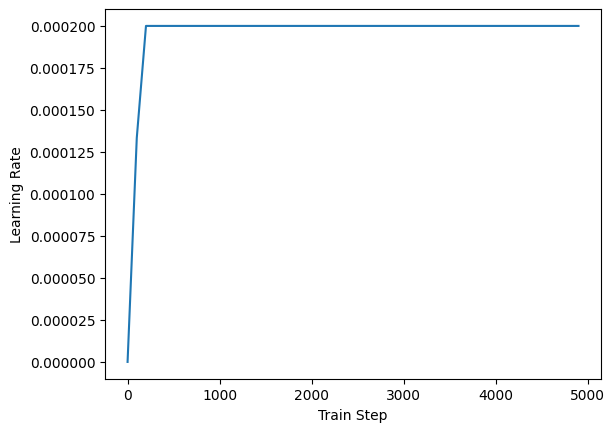

In [20]:
schedule = WarmupSchedule()
x = range(0, 5_000, 100)
y = [keras.ops.convert_to_numpy(schedule(step)) for step in x]
plt.plot(x, y)
plt.xlabel("Train Step")
plt.ylabel("Learning Rate")
plt.show()

#### Fitting the language model

In [34]:
num_epochs = 250 if USE_CUSTOM_DATASET else 8
learning_rate = 0.001

# if we train on Mini-C4, we do only one pass of the entire dataset!
steps_per_epoch = num_train_batches if USE_CUSTOM_DATASET else num_train_batches // num_epochs
validation_steps = num_val_batches

model.compile(
    optimizer=tf.keras.optimizers.Adam(schedule),
    # we use the class here, with `from_logits`: softmax will be applied internally
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[
        # will be `keras.metrics.SparseCategoricalAccuracy()` under the hood
        "accuracy",
        keras_hub.metrics.Perplexity(from_logits=True)
    ],
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=num_epochs,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=[
        PrintStatsCallback(num_epochs),
        tf.keras.callbacks.ModelCheckpoint(
            MODELS_DIR / f"{MODEL_NAME}-gpt.keras",
            monitor="val_loss",
            save_best_only=True,
        )
    ],
    verbose=0,
)

epoch: 250/250 |     batch: 58/58 |     accuracy: 0.5746 –     loss: 1.3438 –     perplexity: 3.8335
               | val batch:  6/ 6 | val_accuracy: 0.4947 – val_loss: 1.7470 – val_perplexity: 5.7373



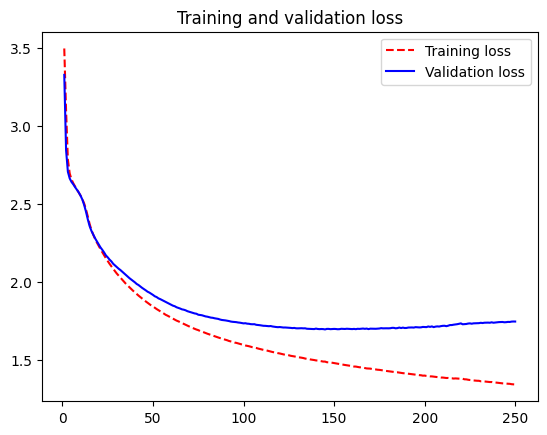

In [35]:
plot_history(history, "loss")

In [36]:
model = keras.models.load_model(MODELS_DIR /f"{MODEL_NAME}-gpt.keras")
stats = model.evaluate(val_ds, steps=validation_steps)

6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4890 - loss: 1.6965 - perplexity: 5.4547


### Generative decoding

#### Sampling Strategies

The **vanilla** way would be just to sample from the softmax output of the model (a probability distribution over the vocab).

This is already smarter than **uniform sampling**, where each token has the same probability (maximum randomness)!

However, we can actually vary the softmax itself (the shape of the probability), to **increase** or **decrease** the level of randomness.

These *intermediate levels of randomness* are controlled by the **softmax temperature** – a fundamental tool for more interesting, creative outputs.

##### Softmax temperature

Remember, the softmax function is:

$$
\bbox[5px,border:2px solid red]
{
\text{softmax}(x_i) = \frac{e^{x_i}}{\sum_i e^{x_i}}
}
$$

$x_i$: logits (scores) for each token in our vocabulary.


It makes all numbers positive and normalises them (all lie between 0 and one and sum to 1) → they are turned into a **probability distribution**.

The parameterised softmax distribution adds a number $T$ like so:

$$
\bbox[5px,border:2px solid red]
{
\text{softmax}(x_i) = \frac{e^{\frac{x_i}{T}}}{\sum_i e^{\frac{x_i}{T}}}
}
$$



```python
def random_sample(preds, temperature=1.0):
    preds = preds / temperature
    return keras.random.categorical(preds[None, :], num_samples=1)[0]
```

###### Usual values for $T$

Depends on the model!

It used to be around 0.9 (most of the time above 0.7, rarely above 1. unless you yearn for delirium!), but lower temperatures (even 0) are used now for very large models.

###### Reweighting a probability distribution to a different temperature

Note that here we use the `log` to (half-)revert the effect of the softmax that the model operates already on its final logits.  In other architectures, the model outputs pre-softmax logits, so you do not need that step and directly divide by the temperature.

In [37]:
def reweight_distribution(original_distribution, temperature=0.5):
    """
    1.a LOG: because `original_distribution` has been softmaxed! (Numerical stability)
      b divide by TEMPERATURE: our reweighting
    2. SOFTMAX: a. exponentiate
                b. divide by the total

    Notes:
        - In many implementations, the log isn't there because the model returns
          logits (before softmax)
        - the last two lines could also be written: `tf.nn.softmax(distribution)`!
    """
    # 1.a + b
    distribution = np.log(original_distribution) / temperature
    # 2.a
    distribution = np.exp(distribution)
    # 2.b
    return distribution / np.sum(distribution)


###### Temperature: limit cases

1. $T \rightarrow 0$:  
    $\frac{x_i}{T} \rightarrow \infty$ so $e^{\frac{x_i}{T}} \rightarrow \infty$, so the highest probability dominates and the $softmax(x_i)$ becomes just $max(x_i)$: the maximum probability dominates – also known as **greedy sampling**;    
    *If the temperature is too low, the model will tend to repeat itself!* (more 'conservative', less creative)...  
    
    
    
2. $T \rightarrow \infty$:  
    $\frac{x_i}{T} \rightarrow 0$ so $e^{\frac{x_i}{T}} \rightarrow 1$ so $q_i \rightarrow \frac{1}{M}$ where $M$ is the number of softmax outputs – a **uniform distribution** (our well-known **random guess**);  
    *If the temperature is too high, the model will tend to 'derail' and stop making sense!*  
    (The formalisation of the link between creativity and madness?) Σ(▼□▼メ)...
    

###### Plotting the effect of softmax temperature

In [38]:
def plot_softmax_temperature():
    # ten random numbers
    nums = tf.random.uniform(shape=(10,))
    # take the log (optional)
    nums = tf.math.log(nums)
    # turned into probabilities
    probs = tf.nn.softmax(nums)

    fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3,2, figsize=(16,12))

    # our ten numbers
    ax1.bar([str(x) for x in range(nums.shape[0])], nums)
    ax1.set_title("Log of ten random numbers")
    ax1.set_ylabel("Original range")

    # the probabilities
    ax2.bar([str(x) for x in range(probs.shape[0])], probs)
    ax2.set_title("Turned into probabilities")
    ax2.set_ylabel("From zero to one")
    ax2.set_ylim([0,1])

    # LOW temperature → very unequal/spiked results
    temp = 0.1
    # reweighting
    weighted_nums = nums / temp
    # turned into probabilities
    probs = tf.nn.softmax(weighted_nums)

    # the probabilities
    ax3.bar([str(x) for x in range(probs.shape[0])], weighted_nums)
    ax3.set_title(f"Reweigted by temperature {temp}")
    ax3.set_ylabel("Increased range")

    # the probabilities
    ax4.bar([str(x) for x in range(probs.shape[0])], probs)
    ax4.set_title("The distribution is more spiked: likelier tokens will almost always get picked")
    ax4.set_ylabel("From zero to one")
    ax4.set_ylim([0,1])

    # HIGH temperature → very equal/flat results
    temp = 10
    # reweighting
    weighted_nums = nums / temp
    # turned into probabilities
    probs = tf.nn.softmax(weighted_nums)

    # the probabilities
    ax5.bar([str(x) for x in range(probs.shape[0])], weighted_nums)
    ax5.set_title(f"Reweigted by temperature {temp}")
    ax5.set_ylabel("reduced range")

    # the probabilities
    ax6.bar([str(x) for x in range(probs.shape[0])], probs)
    ax6.set_title("The distribution is more flat: less likely tokens will be picked alongside likelier ones")
    ax6.set_ylabel("From zero to one")
    ax6.set_ylim([0,1])

    plt.show()

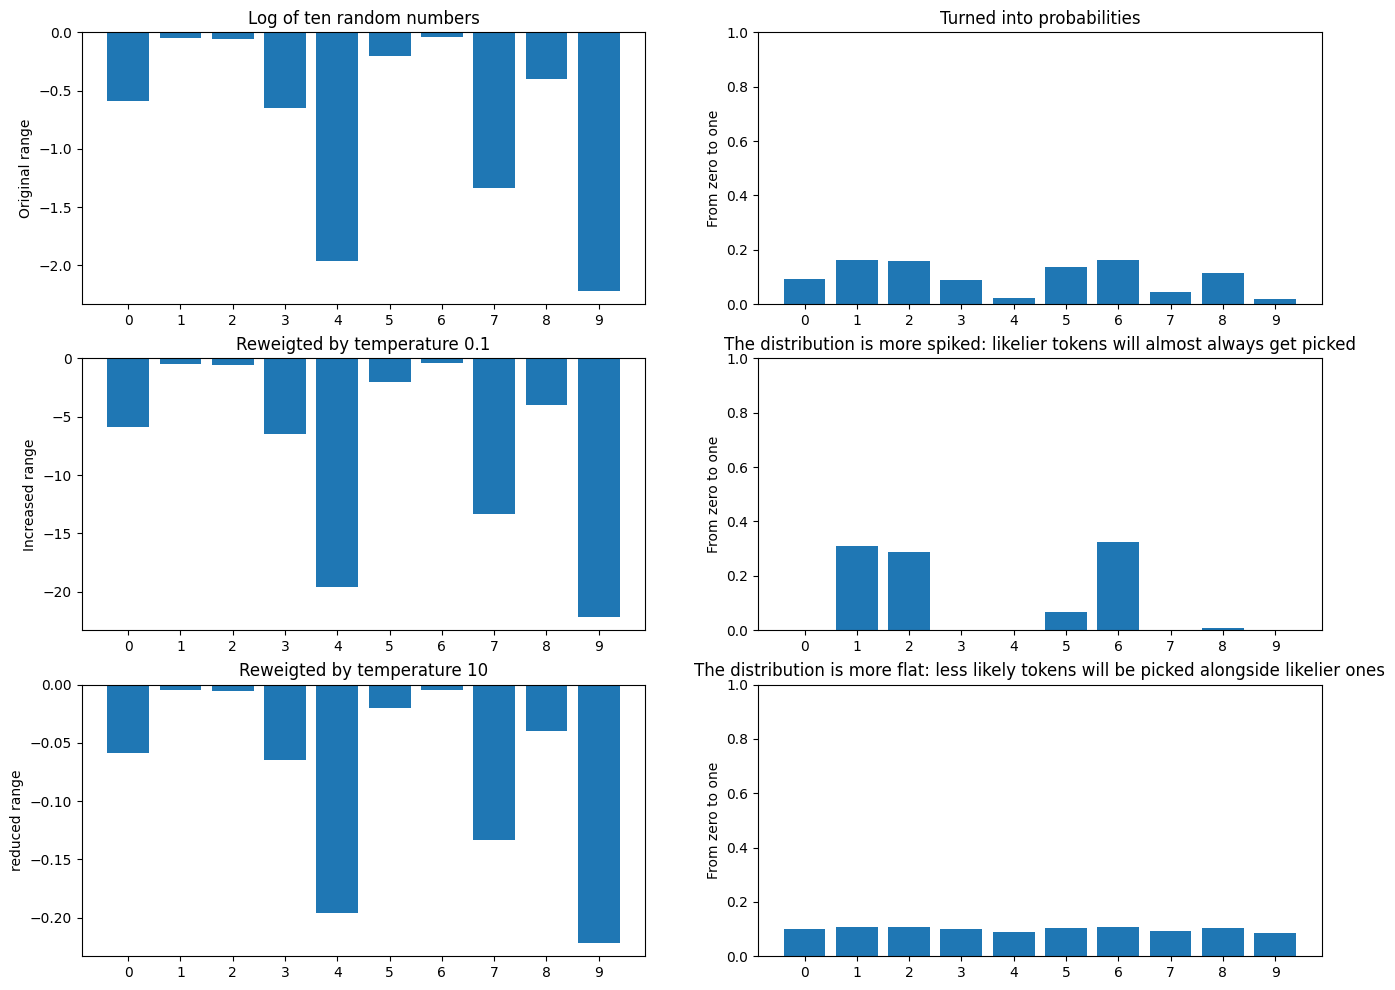

In [39]:
plot_softmax_temperature()

##### Greedy sampling

Always select the **most probable** step. This is called greedy because it is *exactly* the problem you face in real life: pick the best option **now** (= highest reward in the next step) vs have a more long-term strategy (which brings more payoffs in nearly every case).


```python
def greedy_search(preds):
    return keras.ops.argmax(preds)

generate(prompt, greedy_search)
```

##### Top k sampling

Present already in the [GPT-2 paper](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf)), but likely much older.

Sample among the most k probable tokens, reapply softmax, sample from them only


Note also [**Top p (nucleus) sampling**](https://arxiv.org/abs/1904.09751): sample among the most probable token which, combined, amount to a probability of p.

See [Patrick von Platen, "How to generate text: using different decoding methods for language generation with Transformers"](https://huggingface.co/blog/how-to-generate), and the references notebook.

#### Generating text with our LLM

In [40]:
def generate(prompt, sample_fn, max_length=SEQUENCE_LENGTH):
    # convert prompt
    prompt_tokens = list(keras.ops.convert_to_numpy(tokenizer(prompt)))
    prompt_length = len(prompt_tokens)
    # padding, below we always feed a tensor of the same width so that `predict`
    # can *compile* the loop, and make it much faster
    padded = [0] * SEQUENCE_LENGTH + prompt_tokens
    gen_tokens = prompt_tokens.copy()
    for i in range(max_length):
        clear_output(wait=True)
        print(f"{i+1}/{max_length}")
        # here we always pass the last SEQUENCE_LENGTH tokens, so we can keep
        # generating even if max_length > model attention window
        window = (padded + gen_tokens)[-SEQUENCE_LENGTH:]
        # the model outputs log probs (not softmaxed)
        prediction = model.predict(np.array([window]), verbose=0)
        # get the probability for the next token
        prediction = prediction[0, - 1]
        # sample: pick the next token
        next_token = keras.ops.convert_to_numpy(sample_fn(prediction))
        # append to our generated tokens
        gen_tokens.append(next_token.item())
    clear_output(wait=True)
    return tokenizer.detokenize(gen_tokens)

In [41]:
def top_k(preds, k=5, temperature=1.0):
    # we first apply the temperature to the logits
    preds = preds / temperature
    # then we select the top k ones only (top_indices translates back to the original indices)
    top_preds, top_indices = keras.ops.top_k(preds, k=k, sorted=False)
    # sample using log probs: https://keras.io/api/random/random_ops/#categorical-function
    choice = keras.random.categorical(top_preds[None, :], num_samples=1)[0]
    # retrieve token: https://keras.io/api/ops/numpy/#takealongaxis-function
    return keras.ops.take_along_axis(top_indices, choice, axis=-1)

In [42]:
prompt = "JULIET:"

In [43]:
print(generate(prompt, partial(top_k, temperature = 0.8), max_length=512))

JULIET:
O, when here?
A whom what is are sured way?

WARWICK:
I would you have you shall bear me,
That are you may mercy in my heart,
And I will'n my breath.

DUKE VINCENTIO:
Then you are are power: what is is is not?

KING HENRY VI:
I'll me well, and you with him: were hear you,
And there should him.

KING EDWARD IV:
And you, what you must not have shrew you
What was still'd make of me? what I can my father
words my father?

BUCKINGHAM:
I please well am my life.

KING HENRY VI:
And you, I will be honour.

BAPTISTA:
You have you are solder your a


In [44]:
print(generate(prompt, partial(top_k, temperature = 0.1)))

JULIET:
I will not shall be my lord,
And what I would not shall be my father.

KING HENRY VI:
I will not shall be my father.

KING EDWARD IV:
I will you will not shall be your father's grace.

KING EDWARD IV:
I will not shall be my father's father,
And what I would not me


In [46]:
print(generate(prompt, partial(top_k, temperature = 5)))

JULIET:
I work teace arrorated. all any happy:
I hither, angays almorned, and,
Whether too? had, that storme his shoped if arm..
I'
ha! alink thing, a goost sign shade offer: they anorabitinal.

CURLIO.
If witcannot: then were and woo
my forbery ance. twhou, a marce?
A wispectat mon warri


## Save models to Google Drive


In [ ]:
EXPORT=False

if EXPORT:
    # zip models
    !zip gpt.models.zip {MODELS_DIR}/*
    # connect to drive
    from google.colab import drive
    drive.mount('/content/drive')
    # copy zip to drive (adjust folder as needed)
    !cp {MODEL_NAME}-gpt.models.zip drive/MyDrive/gold/IS53024B-Artificial-Intelligence/models

---

## Going further with LLMs

Read about this [in the book](https://deeplearningwithpython.io/chapters/chapter16_text-generation/#using-a-pretrained-llm).

- First off, it's straightforward to do text generation with a pretrained model (using [Gemma 3](https://www.kaggle.com/models/keras/gemma3)).
- **Instruction fine-tuning**: using new training data for the model to make its behaviour be more akin to a chatbot. The dataset contains input/output pairs — a user instruction followed by a model response. This becomes a single sequence with specific formatting (aka *templating*) that we can train on:
  ```
  [instruction]
  Which is a species of fish? Tope or Rope[end]
  [response]
  ```
  The model now trains on continuing this sequence with the right answer. This is still performing the **same training process**, predicting the next token and modelling language, just refining which kinds of sequences we would like (training on them makes them more likely): the model will learn to privilege sequences that answer 'Tope', rather than e.g. continuing the question, for instance. The use of special tokens for `[instruction]`, `[end]`, etc., allows us to control generation more precisely.
- **Low-Rank Adaptation (LoRA)**: in order to save memory and compute, researchers found a way to replace some matrices in the model by others, that project the data to a lower-dimensional space and back again – the input and output dimensions remain the same, but the number of parameters is much less ([paper](https://arxiv.org/abs/2106.09685)!

  <!-- <img style="height: 400px" src="images/chollet/figure16.4.png"> -->
  <img style="height: 300px;" src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/09/images/chollet/figure16.4.png">

  [DLWP](https://deeplearningwithpython.io/chapters/chapter16_text-generation/#low-rank-adaptation-lora), Figure 16.4


    ```python
    class LoraLinear(keras.Layer):
        def __init__(self, input_dim, output_dim, rank):
            super().__init__()
            # the original weight from the model
            self.kernel = self.add_weight(
                shape=(input_dim, output_dim), trainable=False
            )
            # the two matrices for down- and up-projecting
            self.alpha = self.add_weight(shape=(input_dim, rank))
            self.beta = self.add_weight(shape=(rank, output_dim))

        def call(self, inputs):
            # original transformation
            frozen = keras.ops.matmul(inputs, self.kernel)
            # perform the down- and up-projection
            update = keras.ops.matmul(ops.matmul(inputs, self.alpha), self.beta)
            # reinject the information (a bit like a residual connection)
            return frozen + update
    ```


- **Reinforcement Learning with Human Feedback (RLHF)** ([paper](https://arxiv.org/abs/2203.02155)): the issue is that it's difficult to obtain enough well-formed data as we used in supervised fine-tuning. One idea then is to use another model, a so-called **reward model**, that will rate the quality of an entire chat. Given this, and datasets where various conversations are ranked against each other (indicating preference of one over the other), it is then possible to further fine-tune models using the signal from that rewrad model and [Reinforcement Learning](https://huggingface.co/learn/deep-rl-course/en/unit0/introduction) (note that our model is still, as always, trying to predict the next token, no change there). This entire field is called **post-training**, to go extra deep you can have a look at [Nathan Lambert's work](https://rlhfbook.com/).
- **Multimodal LLMs**: the Transformer is not restricted to handling language data. So long as you can transform your data into vectors of the right format, that can then be processed by our attention layers! Vision Transformers then arose, combining two separate encoders (one for text, one for images): the image encoder cuts the image into patches, and turns each of the patches into a so-called *soft token* – because they are not associated with a 'hard' fixed token, like a language one –, thus learning to project image patches into the same vector space, to be then passed down to the attention blocks. The same principle can be applied to audio, video, etc.

  <!-- <img style="height: 400px" src="images/chollet/figure16.6.png"> -->
  <img style="height: 400px" src="https://raw.githubusercontent.com/jchwenger/DLWP/main/lectures/09/images/chollet/figure16.6.png">

  [DLWP](https://deeplearningwithpython.io/chapters/chapter16_text-generation/#low-rank-adaptation-lora), Figure 16.6

- This flexibility – training on vast amounts of data, not even restricted to one specific modality – gives rise to the concept of **foundation model**: a base model that can be used for a wide variety of downstream tasks (and something new in the history of ML – a step towards the 'G', general, of AGI, Artificial General Intelligence).

- Current LLMs have now evolved to use **tools** (by outputting text in a JSON format that can be parsed and then used to invoke a function), and thus retrieve information from either databases, or the web. This process of creating an interface between the LLM and the outside world is called **Retrieval-Augmented Generation (RAG)**, and allows to overcome some limitations of these systems – for instance, their weakness in arithmetic (call a function to do the computation, read the answer), or the cut-off date of their training data (look things up when needed).

- Current LLMs are also trained to do so-called **reasoning**, which is actually just steering the LLM towards writing out the reasoning, or unrolling the process by which it arrives at its answer (famously, [adding "think step-by-step" in the prompt improves performance](https://arxiv.org/abs/2205.11916). This gradual thinking (which still means predicting the next token, but over much longer texts), led to a lot of research (called [Chain-of-Thought](https://arxiv.org/abs/2201.11903)) and the opening of a new 'dimension' of growth: [test-time scaling](https://arxiv.org/abs/2408.03314), i.e. increasing the amount of 'reasoning' (internal steps the LLM produces when answering, by writing out the intermediate steps) while answering (so not during training, hence 'test').

---

## Summary

- We can generate discrete sequence data by training a model to predict the next token(s) given previous tokens.
- **Auto-regressive generation**: the model, conditioned on a sequence, makes a prediction, out of which a token is sampled, that is added to the sequence, and the cycle continues.
- In the case of text, such a model is called a **language model**.
- Language models can be based on **words**, **subwords**, **characters**, **bytes**.
- **Sampling** the next token requires balance between adhering to what the model judges likely, and introducing randomness.
-  **Softmax temperature** and ****top-k** are common tools, alongside other methods.

### Temperature

- **Low**: extremely repetitive and predictable text, often falls into repetition loops
- **Intermediate**: more interesting, surprising, even creative text – sometimes completely new but plausible words are invented
- **High** temperature: local structure breaks down and most words look random

Each model has a sweet spot, but it's usually somewhere in the range 0.7-1., and in my experience more often to be found closer to 0.9!

### Experiments

- Some elements have been taken from the tutorials above, check them out!
- Being patient is a key factor in training: for the Shakespeare corpus, your char model will start making getting ok quality from a loss of around 1.1! The bigger and more diverse your dataset, the bigger that number will be, but you may need to train for longer.
- Note that if you inject some special characters in your dataset, like `<EOS>`, and make sure it is encoded as one integer (token), you can then check for that token when generating! This is how chatbots know when to stop their answers : >.
- Check out the other sampling methods in the references notebook!